# Exploratory Data Analysis (EDA)

## Завантаження бібліотек

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

: 

## Завантаження даних

In [38]:
df = pd.read_csv("data/test.csv")

In [39]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## Початковий аналіз та обробка даних 
(перевірка на пропущені значення, типи фічерів, їх початкова обробка для подальшого аналізу)

In [40]:
# Перевірка розміру датасету
df.shape

(918, 12)

In [41]:
# Перевірка на наявність пропущених значень
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [42]:
# Дивимось на кількість унікальних значень кожного фічера 
# (таким чином можемо знайти категоріальні фічери та їх кількість унікальних значень)
df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [43]:
# Дивимось на типи даних кожного фічера 
# (object часто означає категоріальний фічер у форматі string, який треба буде обробити)
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [44]:
# Переводимо string фічери в числові за допомогою LabelEncoder
sex_encoder = LabelEncoder()
chest_pain_encoder = LabelEncoder()
resting_ecg_encoder = LabelEncoder()
exercise_angina_encoder = LabelEncoder()
st_slope_encoder = LabelEncoder()

df["Sex"] = sex_encoder.fit_transform(df["Sex"])
df["ChestPainType"] = chest_pain_encoder.fit_transform(df["ChestPainType"])
df["RestingECG"] = resting_ecg_encoder.fit_transform(df["RestingECG"])
df["ExerciseAngina"] = exercise_angina_encoder.fit_transform(df["ExerciseAngina"])
df["ST_Slope"] = st_slope_encoder.fit_transform(df["ST_Slope"])

In [45]:
# Переведення категоріальних фічерів у one-hot encoded
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

In [46]:
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_0,ChestPainType_1,ChestPainType_2,ChestPainType_3,RestingECG_0,RestingECG_1,RestingECG_2,ExerciseAngina_0,ExerciseAngina_1,ST_Slope_0,ST_Slope_1,ST_Slope_2
0,40,1,140,289,0,172,0.0,0,False,True,False,False,False,True,False,True,False,False,False,True
1,49,0,160,180,0,156,1.0,1,False,False,True,False,False,True,False,True,False,False,True,False
2,37,1,130,283,0,98,0.0,0,False,True,False,False,False,False,True,True,False,False,False,True
3,48,0,138,214,0,108,1.5,1,True,False,False,False,False,True,False,False,True,False,True,False
4,54,1,150,195,0,122,0.0,0,False,False,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,1.2,1,False,False,False,True,False,True,False,True,False,False,True,False
914,68,1,144,193,1,141,3.4,1,True,False,False,False,False,True,False,True,False,False,True,False
915,57,1,130,131,0,115,1.2,1,True,False,False,False,False,True,False,False,True,False,True,False
916,57,0,130,236,0,174,0.0,1,False,True,False,False,True,False,False,True,False,False,True,False


In [47]:
df.dtypes

Age                   int64
Sex                   int32
RestingBP             int64
Cholesterol           int64
FastingBS             int64
MaxHR                 int64
Oldpeak             float64
HeartDisease          int64
ChestPainType_0        bool
ChestPainType_1        bool
ChestPainType_2        bool
ChestPainType_3        bool
RestingECG_0           bool
RestingECG_1           bool
RestingECG_2           bool
ExerciseAngina_0       bool
ExerciseAngina_1       bool
ST_Slope_0             bool
ST_Slope_1             bool
ST_Slope_2             bool
dtype: object

## Побудова графіків для аналізу даних

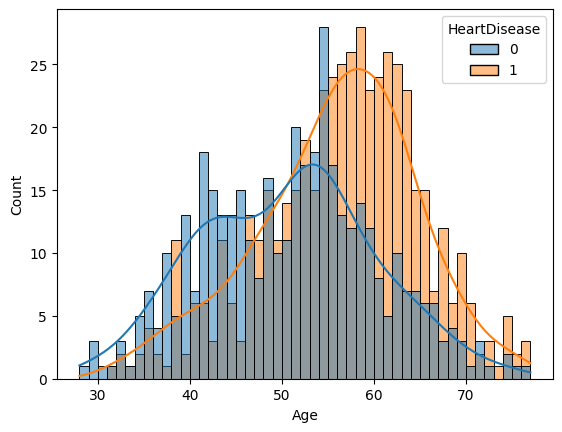

In [48]:
# plt.hist(df["Age"], bins=20)
sns.histplot(data=df, x='Age', hue='HeartDisease', binwidth=1, kde=True)
plt.show()

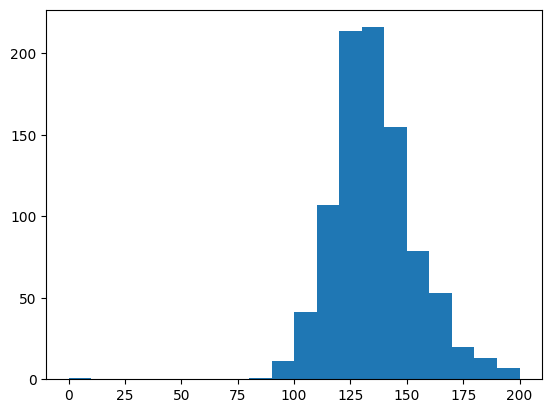

In [49]:
plt.hist(df["RestingBP"], bins=20)
plt.show()

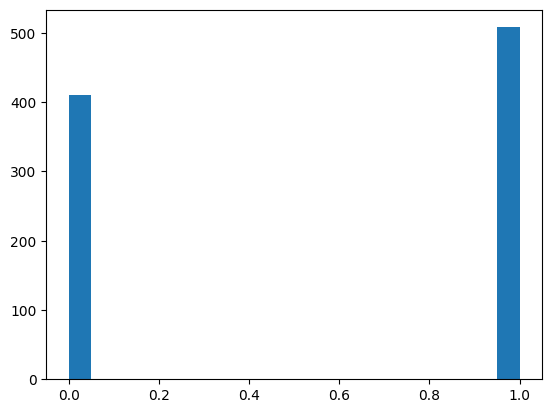

In [50]:
plt.hist(df["HeartDisease"], bins=20)
plt.show()

#### Побудова кореляційної матриці фічерів

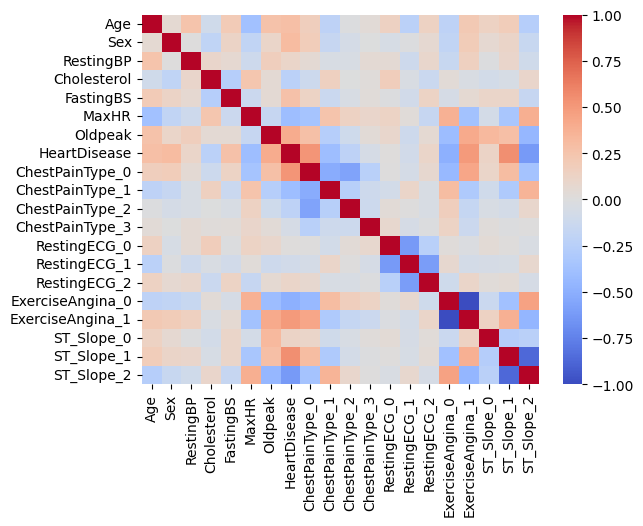

In [51]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Розділ даних

In [52]:
x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

### Спосіб 1: train/val/test split

In [53]:
x_train, x_val_test, y_train, y_val_test = train_test_split(x, y, test_size=0.4, random_state=42)

In [54]:
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=42)

In [55]:
x_train.shape, x_val.shape, x_test.shape

((550, 19), (184, 19), (184, 19))

In [56]:
x_train.to_csv("data/processed_data/x_train.csv", index=False)
x_val.to_csv("data/processed_data/x_val.csv", index=False)
x_test.to_csv("data/processed_data/x_test.csv", index=False)

y_train.to_csv("data/processed_data/y_train.csv", index=False)
y_val.to_csv("data/processed_data/y_val.csv", index=False)
y_test.to_csv("data/processed_data/y_test.csv", index=False)

### Спосіб 2: Cross-validation

In [57]:
kf = KFold(n_splits=4)

In [58]:
c = 1
for train, test in kf.split(x, y):
    print(c)
    c += 1
    print(train.shape)
    print(test.shape)

1
(688,)
(230,)
2
(688,)
(230,)
3
(689,)
(229,)
4
(689,)
(229,)


In [59]:
df.to_csv("data/cv_data/features.csv", index=False)
df.to_csv("data/cv_data/target.csv", index=False)